In [44]:
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    mean_absolute_error, 
    mean_squared_error, 
    r2_score, 
    mean_absolute_percentage_error
)

In [45]:
# Load Data
X_train = pd.read_csv(
    r"C:\Users\norie\Documents\Machine Learning\Projects\intel-daily-stock-price-prediction\data\processed\X_train.csv",
    index_col="Date",
    parse_dates=True
)
X_test = pd.read_csv(
    r"C:\Users\norie\Documents\Machine Learning\Projects\intel-daily-stock-price-prediction\data\processed\X_test.csv",
    index_col="Date",
    parse_dates=True
)
y_train = pd.read_csv(
    r"C:\Users\norie\Documents\Machine Learning\Projects\intel-daily-stock-price-prediction\data\processed\y_train.csv",
    index_col="Date",
    parse_dates=True
)
y_test = pd.read_csv(
    r"C:\Users\norie\Documents\Machine Learning\Projects\intel-daily-stock-price-prediction\data\processed\y_test.csv",
    index_col="Date",
    parse_dates=True
)

In [46]:
# Converting DataFrame into Series
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [47]:
# Load Scaler
scaler = joblib.load(r"C:\Users\norie\Documents\Machine Learning\Projects\intel-daily-stock-price-prediction\models\scaler.joblib")

In [48]:
# Scaling
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
lr_pred = lr_model.predict(X_test_scaled)

print("Coefficient:", lr_model.coef_[0])
print("Intercept:", lr_model.intercept_)
print("Predictions:", lr_pred)

print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R² Score:", r2_score(y_test, lr_pred))

Coefficient: -0.5063025563872012
Intercept: 35.34238614354815
Predictions: [20.02916923 20.54962708 20.40661328 20.08252042 20.06793559 20.6747156
 20.36458522 20.00201297 20.34060925 21.06447612 21.4584643  22.28742199
 22.65660733 21.55085786 21.54911546 21.66375739 21.38917605 21.31939313
 20.74098867 20.61987544 20.10940522 20.60862036 20.4877951  20.34508846
 19.59748373 19.79955136 20.29215001 20.34494735 20.09241755 20.17626042
 20.57962558 21.99865469 20.6982285  20.8059934  20.18970751 20.75640288
 20.90029332 21.49667343 21.14202748 21.21658155 22.5191929  22.28443646
 22.55525531 22.74897637 22.42327434 22.85466403 21.84598968 22.48898497
 22.04073353 23.51946802 23.5095434  23.88017756 23.45793432 23.28072098
 22.95989812 22.65746465 22.85109384 23.16934245 23.36059394 23.31678025
 23.5022114  22.67791456 20.65854799 20.73512903 20.47431566 20.41625109
 19.90442646 19.36996416 19.62117057 20.30830907 20.50700082 19.89140423
 20.01780671 20.79090664 21.8068267  22.24024331 2

In [67]:
from sklearn.svm import SVR

svr_model = SVR(kernel="rbf", C=1000, gamma=0.1, epsilon=0.001)
svr_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,tol,0.001
,C,1000
,epsilon,0.001
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [68]:
svr_pred = svr_model.predict(X_test_scaled)

In [70]:
print("MAE:", mean_absolute_error(y_test, svr_pred))
print("MSE:", mean_squared_error(y_test, svr_pred))
print("R²:", r2_score(y_test, svr_pred))

MAE: 2.8901831137267275
MSE: 62.982444283584385
R²: 0.6672087413476242


In [73]:
import lightgbm as lgb

train_data = lgb.Dataset(X_train_scaled, label=y_train)
test_data = lgb.Dataset(X_test_scaled, label=y_test, reference=train_data)

params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.01,
    "num_leaves": 25,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 3,
    "verbose": -1
}

# Train model
model = lgb.train(
    params,
    train_data,
    valid_sets=[test_data],
    num_boost_round=1000
)

In [74]:
y_pred = model.predict(X_test_scaled)

# Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MAE: 2.0922595114337663
MSE: 27.37495893765338
R²: 0.8553541841056616


In [85]:
single_input = pd.DataFrame([{
    "Open": 121.45,
    "High": 123.08,
    "Low": 116.31,
    "Close": 117.45,
    "MA5": 120.22,
    "MA14": 117.53,
    "High-Low Range": 6.77
}])

single_scale = scaler.transform(single_input)

In [86]:
prediction = lr_model.predict(single_scale)

print("Predicted Target:", prediction[0])

Predicted Target: 116.65344173555044


In [18]:
prediction = svr_model.predict(single_scale)

print("Predicted Target:", prediction[0])

Predicted Target: 0.028351878291061054


In [15]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.001,
    max_depth=10,
    random_state=42
)

In [16]:
xgb_model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [17]:
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

mape = mean_absolute_percentage_error(y_test, y_pred)

# Adjusted R2
n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

print("\n===== Regression Metrics =====")

print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R2    : {r2:.4f}")
print(f"Adj R2: {adjusted_r2:.4f}")
print(f"MAPE  : {mape:.4f}")


===== Regression Metrics =====
MAE   : 2.1131
MSE   : 26.7139
RMSE  : 5.1685
R2    : 0.8588
Adj R2: 0.8548
MAPE  : 0.0444


In [19]:
# Using Neural Network for Linear Regression
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

nn_model_lr = tf.keras.Sequential([
    tf.keras.Input(shape=(7,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

nn_model_lr.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history = nn_model_lr.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [20]:
nn_pred = nn_model_lr.predict(X_test_scaled).flatten()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


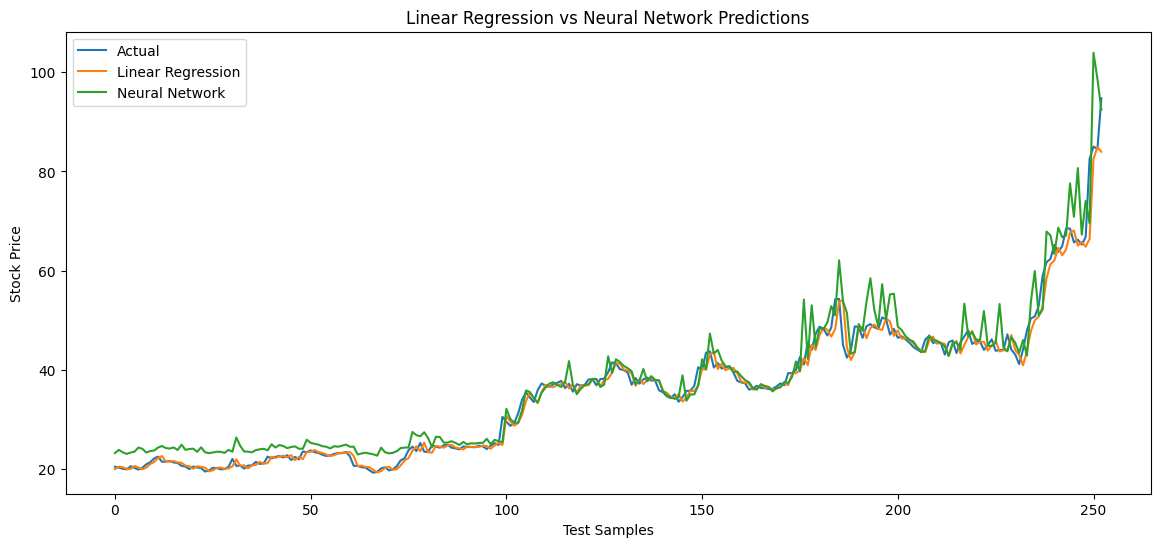

In [22]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(14,6))

# Actual values
plt.plot(y_test.values, label='Actual')

# Linear Regression predictions
plt.plot(lr_pred, label='Linear Regression')

# Neural Network predictions
plt.plot(nn_pred, label='Neural Network')

# Labels and title
plt.title('Linear Regression vs Neural Network Predictions')
plt.xlabel('Test Samples')
plt.ylabel('Stock Price')

# Legend
plt.legend()

# Show plot
plt.show()

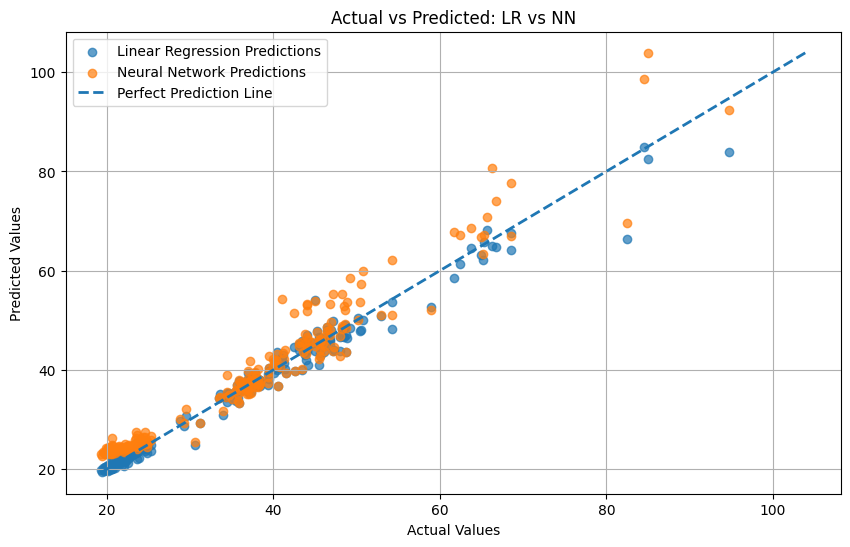

In [26]:
# Create figure
plt.figure(figsize=(10,6))

# Scatter plots
plt.scatter(y_test, lr_pred, label='Linear Regression Predictions', alpha=0.7)
plt.scatter(y_test, nn_pred, label='Neural Network Predictions', alpha=0.7)

# Perfect prediction line (Actual = Predicted)
min_val = min(y_test.min(), lr_pred.min(), nn_pred.min())
max_val = max(y_test.max(), lr_pred.max(), nn_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction Line'
)

# Labels
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted: LR vs NN')

# Legend
plt.legend()

# Grid
plt.grid(True)

# Show plot
plt.show()

In [77]:
df = pd.read_csv(
    r"C:\Users\norie\Documents\Machine Learning\Projects\intel-daily-stock-price-prediction\data\processed\intel-daily-stock-price-data-processed.csv",
    index_col="Date",
    parse_dates=True
                )

X = df.drop("Target", axis=1)
y = df["Target"]

X_scaled = scaler.transform(X)

In [79]:
# Linear Regression Cross-Validation
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

tscv = TimeSeriesSplit(n_splits=5)

cv_model = LinearRegression()

scores = []

for train_idx, test_idx in tscv.split(X):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    cv_model.fit(X_train, y_train)

    preds = cv_model.predict(X_test)

    scores.append(r2_score(y_test, preds))

print("R² scores:", scores)
print("Average R²:", np.mean(scores))

R² scores: [0.961227451103451, 0.9542931689936692, 0.978501846004064, 0.8118312437936972, 0.9722511986980642]
Average R²: 0.935620981718589


In [81]:
# XGBoost Cross Validation
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# Store scores
xgb_scores = []

# 

# Cross validation loop
for train_idx, test_idx in tscv.split(X_scaled):

    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Train
    xgb_model.fit(X_train, y_train)

    # Predict
    preds = xgb_model.predict(X_test)

    # Evaluate
    score = r2_score(y_test, preds)
    xgb_scores.append(score)

# Results
print("XGBoost R² scores:", xgb_scores)
print("Average R²:", np.mean(xgb_scores))

XGBoost R² scores: [-1.6210043791287752, 0.8893212914347338, 0.9367016755279017, 0.7158964153810895, 0.8163194461013088]
Average R²: 0.3474468898632518


In [83]:
# LightGBM Cross Validation

# Store scores
lgb_scores = []

# Cross-validation loop
for train_idx, test_idx in tscv.split(X_scaled):

    # Split data
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Create LightGBM datasets
    train_data = lgb.Dataset(X_train, label=y_train)
    test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

    # Parameters
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "learning_rate": 0.01,
        "num_leaves": 25,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 3,
        "verbose": -1
    }

    # Train model
    model = lgb.train(
        params,
        train_data,
        valid_sets=[test_data],
        num_boost_round=1000
    )

    # Predictions
    preds = model.predict(X_test)

    # R² score
    score = r2_score(y_test, preds)

    # Store score
    lgb_scores.append(score)

# Results
print("LightGBM R² scores:", lgb_scores)
print("Average R²:", np.mean(lgb_scores))

LightGBM R² scores: [-1.9969534626784005, 0.9007962992299643, 0.9432016856627854, 0.17524747180131672, 0.8124081268589403]
Average R²: 0.16694002417492124
